In [1]:
from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from algorithms.smc import particle_filter
from time import perf_counter
import seaborn as sb

from utilities.helpers import (
    autocorrelation,
    auto_window,
    autocorr_new,
    effective_sample_size,
)

is_accelerator = jax.devices()[0].platform != "cpu"
print(f"Using Accelerator: {is_accelerator}")

Using Accelerator: True


In [2]:
def model(x0, theta, key, t_range):
    delta_t = t_range[1] - t_range[0]

    exp_theta = jnp.exp(theta)

    gamma, xi, alpha, eta, damping, log_mean, log_std = exp_theta
    log_beta_damping = damping
    log_beta_mean = jnp.log(log_mean)
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, H, R, log_beta = prev_x

        N = S + I + R + H

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 6)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        new_S = jax.random.poisson(update_keys[1], xi * R * delta_t)

        new_I = jax.random.poisson(
            update_keys[2], (jnp.exp(log_beta) * S * I) / N * delta_t
        )
        new_IH = jax.random.poisson(update_keys[3], alpha * gamma * I * delta_t)
        new_HR = jax.random.poisson(update_keys[4], eta * H * delta_t)
        new_IR = jax.random.poisson(update_keys[5], alpha * (1 - gamma) * I * delta_t)

        S = jnp.maximum(0.0, S + new_S - new_I)
        I = jnp.maximum(0.0, I + new_I - (new_IH + new_IR))
        H = jnp.maximum(0.0, H + new_IH - new_HR)
        R = jnp.maximum(0.0, R + new_HR + new_IR - new_S)

        return (jnp.array([S, I, H, R, log_beta]), next_key), jnp.array(
            [S, I, H, R, log_beta]
        )

    _, loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis, :], loop_val))

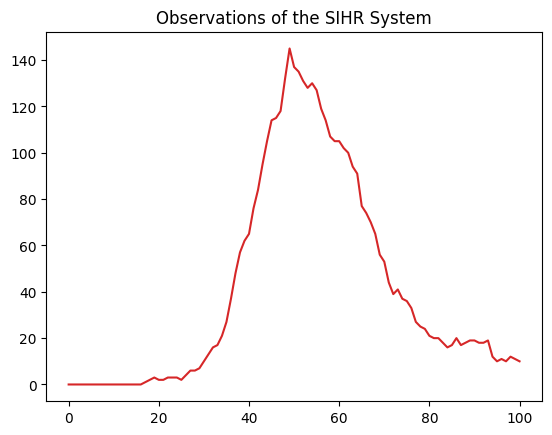

In [3]:
theta = jnp.log(jnp.array([1 / 1000, 1 / 90, 1 / 7, 1 / 7, 1 / 35, 0.35, 0.2]))
delta_t = 1.0
days = 100
rng_key = jax.random.key(0)
t_range = jnp.arange(0, days + delta_t, delta_t)


SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=100, shape=())

x0 = jnp.full(shape=(4), fill_value=jnp.array([500_000.0, 0.0, 0.0, 0.0]))

x0 = x0.at[0].set(x0[0] - I_x0)
x0 = x0.at[1].set(x0[1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key, minval=0.1, maxval=0.5)

beta_x0 = beta_x0[..., jnp.newaxis]

x0 = jnp.concatenate((x0, jnp.log(beta_x0)), axis=-1)

run_key, rng_key = jax.random.split(rng_key)
full_state = model(x0, theta, run_key, t_range)

observations = full_state[:, -3]

plt.title("Observations of the SIHR System")
plt.plot(
    t_range,
    observations.T,
    color="tab:red",
)
plt.show()

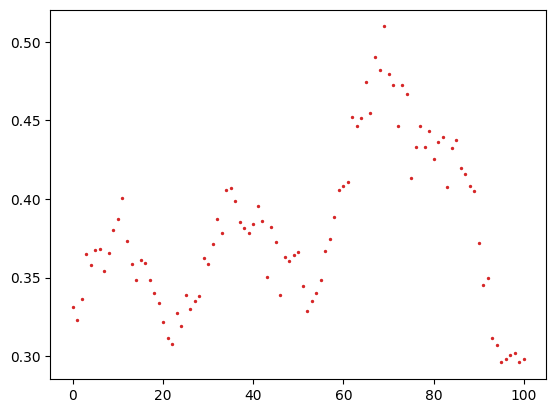

In [4]:
plt.scatter(
        t_range,
        jnp.exp(full_state[:,-1]).T,
        color="tab:red",
        s = 2.0,
        zorder=100
    )

In [5]:
def likelihood(particles, observation, par):
    return jax.scipy.stats.poisson.logpmf(observation, mu=particles[:, 2] + 0.001)

In [6]:
def f(par, observations, m, key):
    mask = jnp.arange(observations.shape[0]) < m

    num_particles = 100
    key, init_key = jax.random.split(key)
    I_x0 = jax.random.randint(init_key, minval=0, maxval=100, shape=(num_particles,))

    particles = jnp.full(
        shape=(num_particles, 5), fill_value=jnp.array([500_000.0, 0.0, 0.0, 0.0, 0.0])
    )
    beta_x0 = jax.random.uniform(
        beta_init_key, shape=(num_particles,), minval=0.1, maxval=0.5
    )

    particles = particles.at[:, 0].set(particles[:, 0] - I_x0)
    particles = particles.at[:, 1].set(particles[:, 1] + I_x0)

    particles = particles.at[:, -1].set(jnp.log(beta_x0))

    particles, log_weights = particle_filter(
        model,
        observations,
        particles,
        key,
        likelihood,
        par,
        jnp.linspace(0, 1, 2),
    )

    log_means = jax.scipy.special.logsumexp(log_weights, axis=0) - jnp.log(
        num_particles
    )

    return jnp.sum(jnp.where(mask, log_means, 0.0))

In [7]:
from algorithms.smc import ibis

num_particles = 10_000
dim = 7
scale = 0.1
p_init_key, rng_key = jax.random.split(rng_key)
particles = jnp.log(
    jnp.array([0.005, 0.01, 0.1, 0.1, 0.1, 0.1, 0.1])
) + scale * jax.random.normal(p_init_key, shape=(num_particles, dim))


k = 5
ibis_key, key = jax.random.split(rng_key)
particles = ibis(f, observations, k, particles, ibis_key)

Iteration 0 with ESS 10000.0029296875
Iteration 1 with ESS 9998.9375
Iteration 2 with ESS 9997.224609375
Iteration 3 with ESS 9994.8779296875
Iteration 4 with ESS 9991.875
Iteration 5 with ESS 9988.1884765625
Iteration 6 with ESS 9983.689453125
Iteration 7 with ESS 9978.7529296875
Iteration 8 with ESS 9972.8291015625
Iteration 9 with ESS 9966.4853515625
Iteration 10 with ESS 9959.51171875
Iteration 11 with ESS 9951.759765625
Iteration 12 with ESS 9943.8876953125
Iteration 13 with ESS 9935.1298828125
Iteration 14 with ESS 9925.5126953125
Iteration 15 with ESS 9916.4365234375
Iteration 16 with ESS 9905.97265625
Iteration 17 with ESS 9895.54296875
Iteration 18 with ESS 8843.5439453125
Iteration 19 with ESS 8801.8955078125
Iteration 20 with ESS 8562.841796875
Iteration 21 with ESS 8521.439453125
Iteration 22 with ESS 8482.6455078125
Iteration 23 with ESS 8270.806640625
Iteration 24 with ESS 8125.455078125
Iteration 25 with ESS 8022.95068359375
Iteration 26 with ESS 8091.99169921875
Iterati

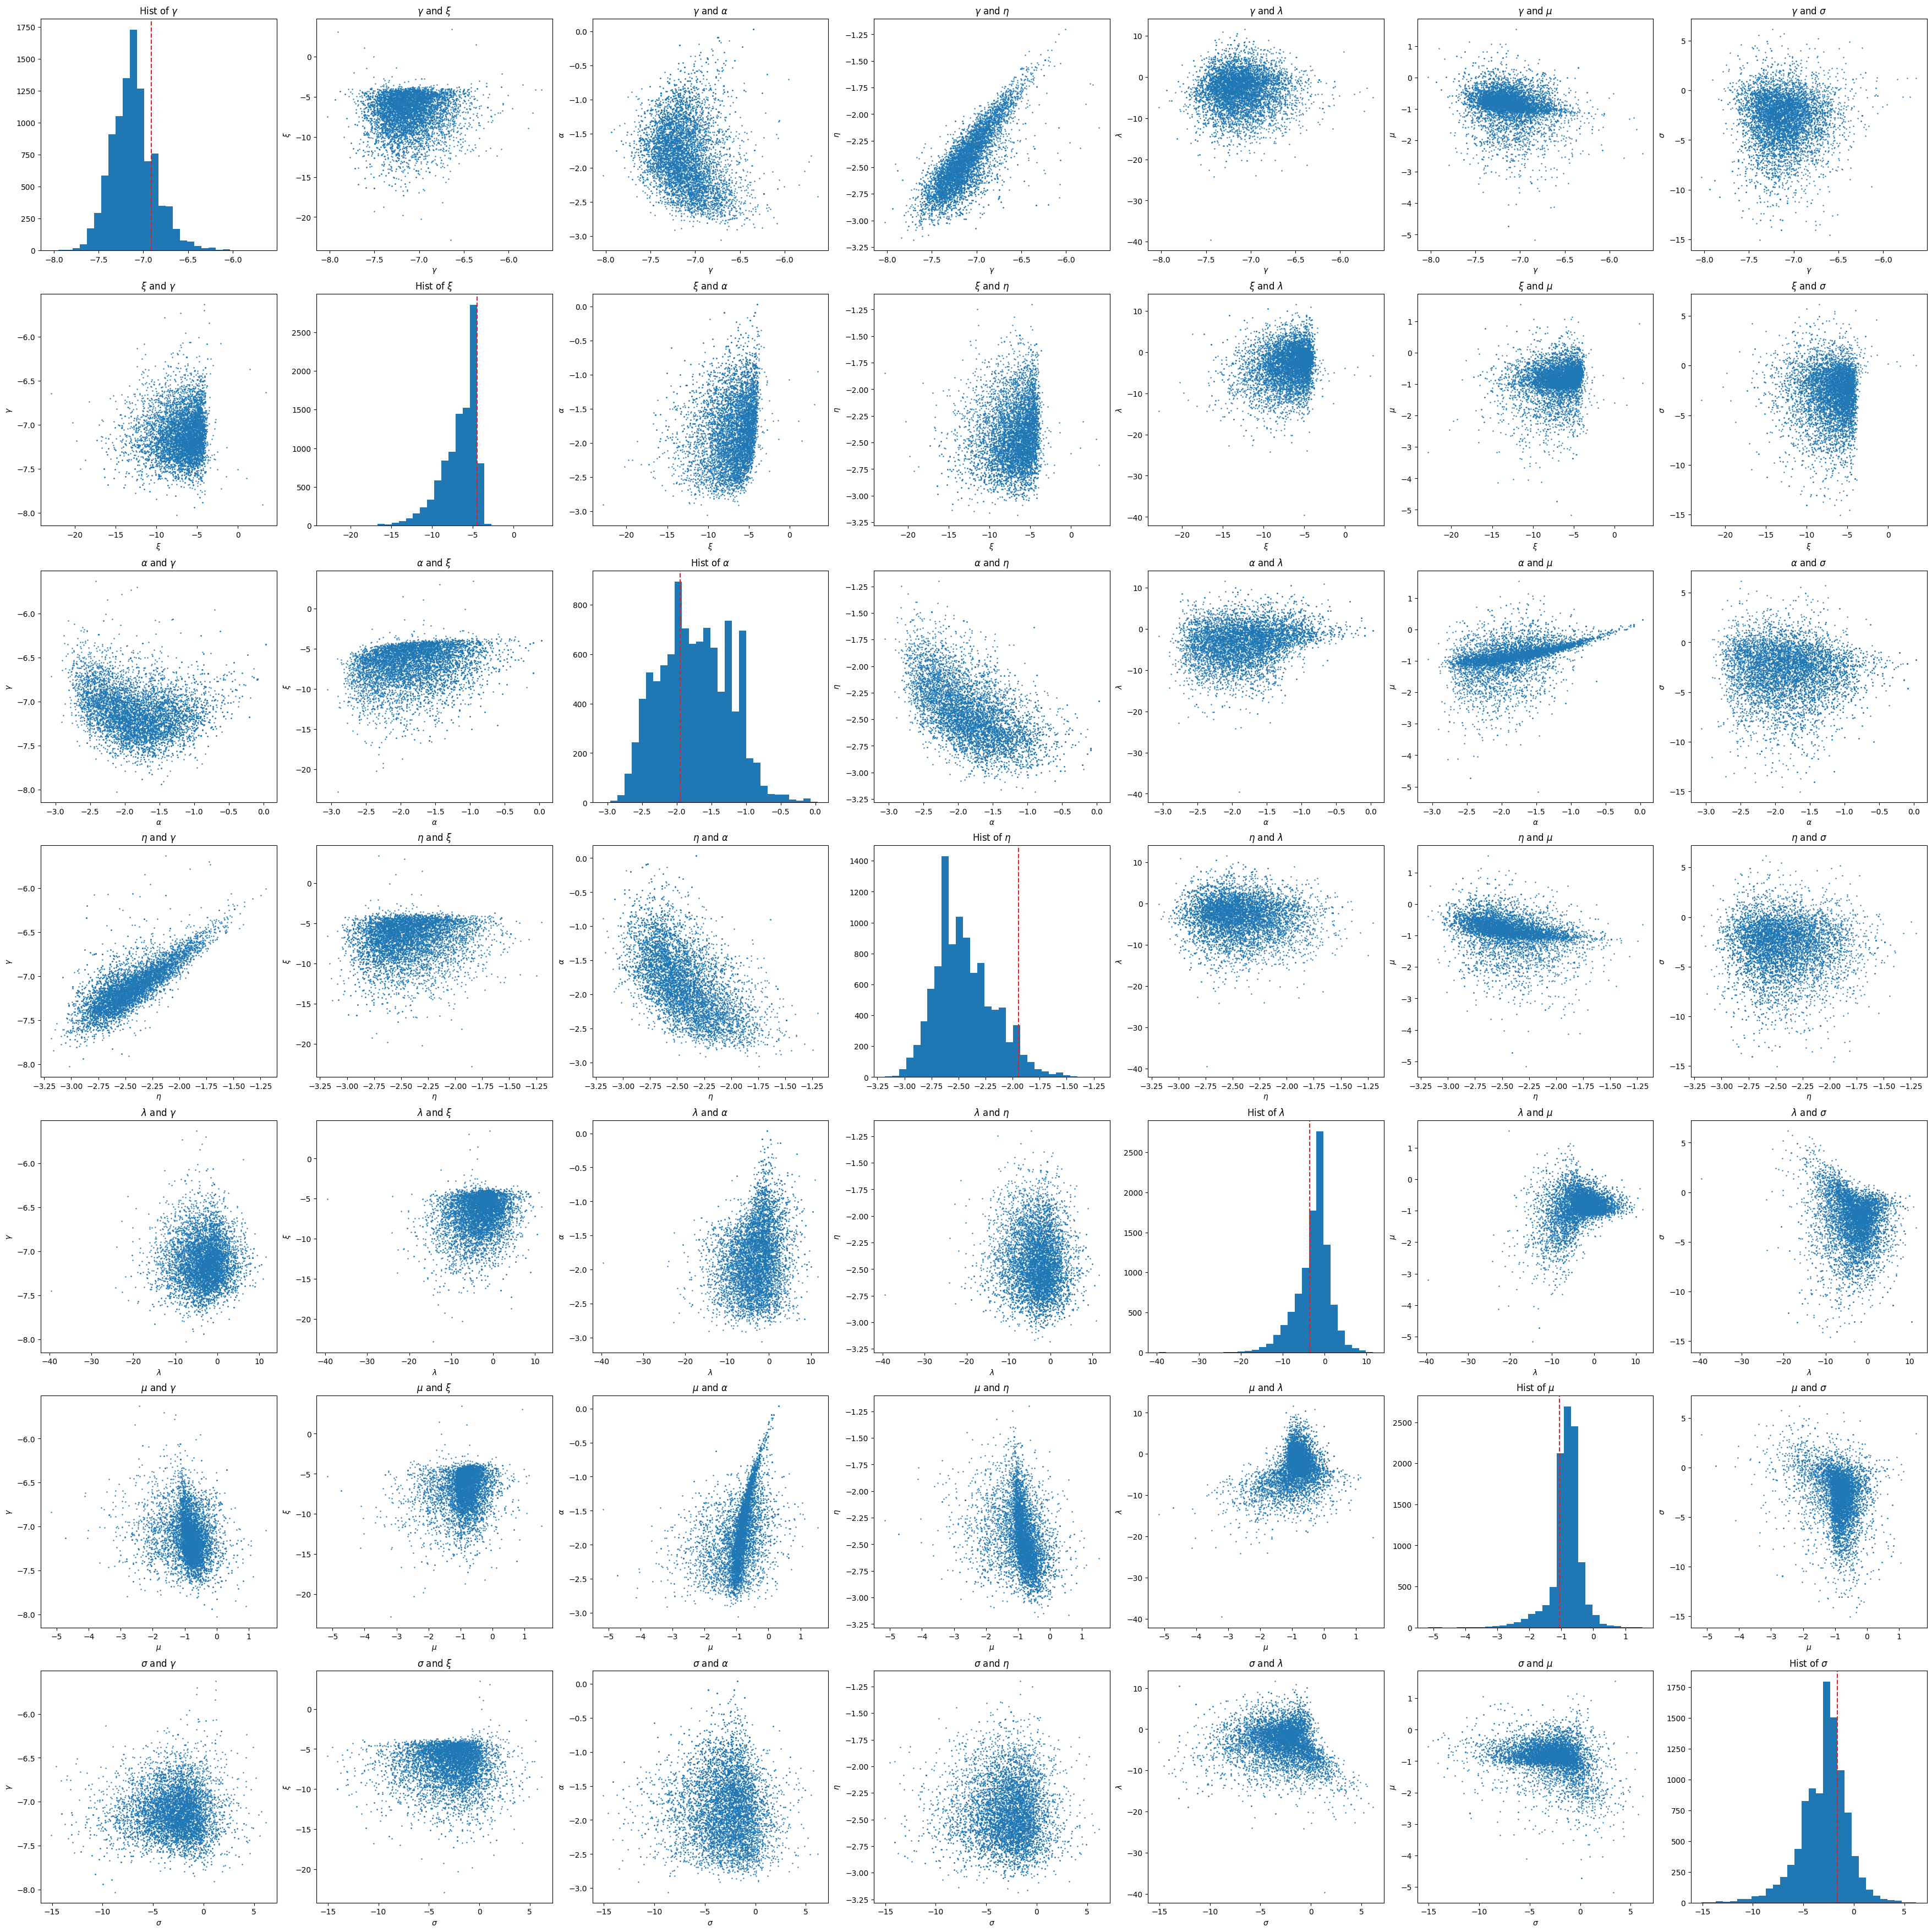

In [8]:
fig, axes = plt.subplots(dim, dim, figsize=(5 * dim, 5 * dim), layout="constrained")

par_names = ["$\\gamma$", "$\\xi$","$\\alpha$","$\\eta$","$\\lambda$", "$\\mu$","$\\sigma$"]

for par1_index in range(dim):
    for par2_index in range(dim):
        if par1_index != par2_index:
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            axes[par1_index, par2_index].scatter(
                particles[:, par1_index],
                particles[:, par2_index],
                s=0.5,
            )
            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")

        else:
            axes[par1_index, par2_index].hist(particles[:, par1_index], bins=30)
            axes[par1_index, par2_index].set_title(f"Hist of {par_names[par1_index]}")
            axes[par1_index, par2_index].axvline(
                theta[par1_index], color="tab:red", ls="dashed"
            )

plt.show()